### IMPORTS

In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(".."))

from sklearn.metrics import confusion_matrix, accuracy_score

from src.dataset import get_dataloaders
from src.model import get_model

### LOAD RESULTS

In [5]:
results = {
    "baseline": {
        "val_acc": 0.53,
        "val_loss": 1.24
    },
    "augment": {
        "val_acc": 0.27,
        "val_loss": 1.28
    },
    "synthetic": {
        "val_acc": None,   # fill this
        "val_loss": None
    },
    "combined": {
        "val_acc": None,   # fill this
        "val_loss": None
    }
}

### RESULTS TABLE:

In [7]:
results = {
    "baseline": {
        "val_acc": 0.53,
        "val_loss": 1.24
    },
    "augment": {
        "val_acc": 0.27,
        "val_loss": 1.28
    },
    "synthetic": {
        "val_acc": 0.47,
        "val_loss": 1.18
    },
    "combined": {
        "val_acc": 0.33,
        "val_loss": 1.22
    }
}

In [8]:
for config, vals in results.items():
    print(f"{config.upper():<10} | Val Acc: {vals['val_acc']} | Val Loss: {vals['val_loss']}")

BASELINE   | Val Acc: 0.53 | Val Loss: 1.24
AUGMENT    | Val Acc: 0.27 | Val Loss: 1.28
SYNTHETIC  | Val Acc: 0.47 | Val Loss: 1.18
COMBINED   | Val Acc: 0.33 | Val Loss: 1.22


### OBSERVATIONS OF FINAL RESULTS:  
While synthetic data improved training stability and reduced validation loss, it did not outperform the baseline in accuracy. Data augmentation significantly degraded performance, likely due to the small dataset size and the sensitivity of the classification task to subtle visual features. Combining augmentation with synthetic data further reduced performance, suggesting that excessive transformations can obscure important structural cues in residential imagery.

### SET BEST MODEL

In [10]:
best_config = "baseline"

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_, _, test_loader, classes = get_dataloaders(
                                    data_dir="../data",
                                    config=best_config)

model = get_model(num_classes=len(classes))
model.load_state_dict(torch.load(f"../outputs/models/{best_config}_model.pth"))
model.to(device)
model.eval()

/Users/emilycastelan/.venvs/pymc-env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/emilycastelan/.venvs/pymc-env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

### GET PREDICTIONS:

In [16]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

### COMPUTE TEST ACCURACY:

In [17]:
from sklearn.metrics import accuracy_score

test_acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.3500


### CONFUSION MATRIX:

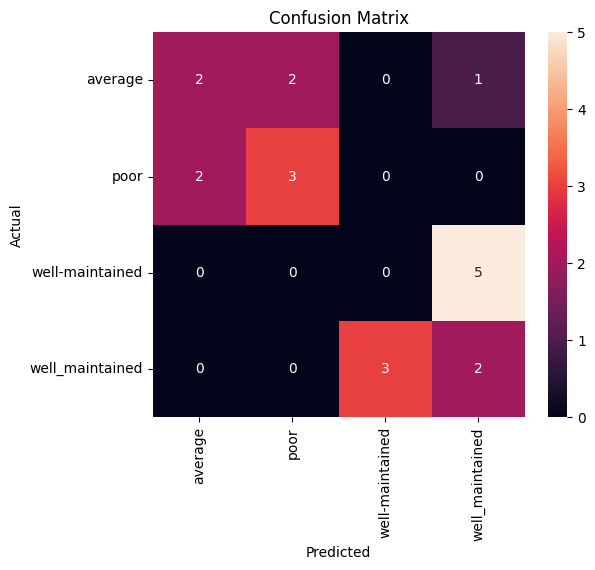

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()